In [30]:
import numpy as np
import pandas as pd
from numpy.fft import fft, ifft
import matplotlib.pyplot as plt
from params import conn_features, COVARS
import shap

import seaborn as sns

PATH = "/Users/vladimiromelyusik/processed_data.csv"

from neuro_spec import ANAT_COLS, BOLD_COLS, DMN, SN, ECN

import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.ensemble import RandomForestRegressor
from itertools import product

In [25]:
data = pd.read_csv(PATH)
data[["area", "hem"]] = data["ROI"].str.split("-", expand = True)
data.head()

,subject,ROI,NumVert,SurfArea_mm2,GrayVol_mm3,ThickAvg_mm,ThickStd_mm,MeanCurv_mm-1,GausCurv_mm-2,FoldInd,CurvInd,Study Name,YrsEdu,Age,Sex,Race,SmkStatus,CPD,YrsSmk,PckYrs,CO,BISatten,BISmotor,BISnonplan,BISTot,CES-D,FTND,QSUb_int-desire,QSUb_relief,QSUb_total,Streaking,Anatomical,BrainSegVolNotVent_mm3,RepetitionTime,ts_0,ts_1,ts_2,ts_3,ts_4,ts_5,...,ts_682,ts_683,ts_684,ts_685,ts_686,ts_687,ts_688,ts_689,ts_690,ts_691,ts_692,ts_693,ts_694,ts_695,ts_696,ts_697,ts_698,ts_699,ts_700,ts_701,ts_702,ts_703,ts_704,ts_705,ts_706,ts_707,ts_708,ts_709,ts_710,ts_711,ts_712,ts_713,ts_714,ts_715,ts_716,ts_717,ts_718,ts_719,area,hem
0,1005,bankssts-lh,1559,1074,2704,2.654,0.475,0.096,0.016,9,1.1,SmokeEmote,16.0,22,1,3,1,0.0,0,0.0,1,12.0,14.0,14.0,40.0,26,NaN,NaN,NaN,NaN,False,fsaverage6,1052296.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bankssts,lh
1,1005,bankssts-rh,1116,815,2039,2.705,0.490,0.098,0.013,6,0.7,SmokeEmote,16.0,22,1,3,1,0.0,0,0.0,1,12.0,14.0,14.0,40.0,26,NaN,NaN,NaN,NaN,False,fsaverage6,1052296.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bankssts,rh
2,1005,caudalanteriorcingulate-lh,909,608,1722,2.317,0.765,0.116,0.014,9,0.6,SmokeEmote,16.0,22,1,3,1,0.0,0,0.0,1,12.0,14.0,14.0,40.0,26,NaN,NaN,NaN,NaN,False,fsaverage6,1052296.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,caudalanteriorcingulate,lh
3,1005,caudalanteriorcingulate-rh,911,649,1656,2.305,0.598,0.141,0.017,15,0.7,SmokeEmote,16.0,22,1,3,1,0.0,0,0.0,1,12.0,14.0,14.0,40.0,26,NaN,NaN,NaN,NaN,False,fsaverage6,1052296.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,caudalanteriorcingulate,rh
4,1005,caudalmiddlefrontal-lh,3108,2184,6452,2.691,0.507,0.117,0.023,26,2.8,SmokeEmote,16.0,22,1,3,1,0.0,0,0.0,1,12.0,14.0,14.0,40.0,26,NaN,NaN,NaN,NaN,False,fsaverage6,1052296.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,caudalmiddlefrontal,lh


In [26]:
def autocorr_decay_matrix(X):
    Xc = X - X.mean(axis=1, keepdims=True)

    # FFT-based autocorrelation
    F = fft(Xc, axis=1)
    ac = np.real(ifft(F * np.conj(F), axis=1))
    ac = ac[:, :X.shape[1]]
    ac /= ac[:, [0]]

    n_series, n_time = ac.shape
    t = np.arange(n_time)

    lambdas = np.empty(n_series)

    for i in range(n_series):
        ac_i = ac[i]

        # keep only positive part
        pos_mask = ac_i > 0
        if not np.any(pos_mask):
            lambdas[i] = np.nan
            continue

        ac_pos = ac_i[pos_mask]
        t_pos = t[pos_mask]

        # enforce monotonic decay
        ac_pos = np.minimum.accumulate(ac_pos)

        # avoid log(0)
        eps = 1e-8
        y = np.log(ac_pos + eps)

        # linear fit: log(ac) = -t/λ + c
        slope, intercept = np.polyfit(t_pos, y, 1)
        lambdas[i] = -1 / slope if slope < 0 else np.nan

    return lambdas


In [72]:
network = ECN

In [73]:
data_anat_features = []
data_func_features = []
covars = []
target = []

for subject in data["subject"].unique():

    target_value = data[data["subject"] == subject]["FTND"].iloc[0]
    if pd.isna(target_value): continue
    target.append(target_value)

    data_subject = data[data["subject"] == subject]
    data_subject = data_subject[data_subject["area"].isin(network)]
    roi = data_subject["ROI"]
    covars.append(data_subject[COVARS].iloc[0].to_numpy())

    data_anat_features.append(data_subject[ANAT_COLS].to_numpy().flatten())

    # Get functional features
    bold_matrix = data_subject[BOLD_COLS].dropna(axis = 1).to_numpy()
    bold_std = np.std(bold_matrix, axis = 1)
    
    # Z-score
    bold_matrix = (bold_matrix - np.mean(bold_matrix, axis = 1, keepdims = True)) / np.std(bold_matrix, axis = 1, keepdims = True)

    # Dominant frequency
    freqs = np.fft.rfftfreq(bold_matrix.shape[1], d = 1) # BOLD data are sampled to 1 Hz
    fft_vals = np.abs(np.fft.rfft(bold_matrix, axis = 1))
    dominant_freq = freqs[np.argmax(fft_vals, axis = 1)]
    autocorr_decay = autocorr_decay_matrix(bold_matrix)
    

    data_func_features.append(np.stack([bold_std, dominant_freq, autocorr_decay]).T.flatten())

data_anat_features = pd.DataFrame(np.array(data_anat_features), columns = [f"{e[0]}_{e[1]}" for e in list(product(roi.to_list(), ANAT_COLS))])
data_func_features = pd.DataFrame(np.array(data_func_features), columns = [f"{e[0]}_{e[1]}" for e in list(product(roi.to_list(), ["std", "dom_freq", "lambd"]))])
covars = pd.DataFrame(np.array(covars), columns = COVARS)
target = np.array(target, dtype = int)

In [74]:
features = data_anat_features

In [75]:
model = OrderedModel(
    target,
    pd.concat([features, covars], axis = 1),
    distr = "logit"
)
res = model.fit(method='bfgs')

significant = pd.DataFrame(res.params[res.pvalues < 0.05]).reset_index()
significant.columns = ["feature", "coef"]
significant["pval"] = res.pvalues[res.pvalues < 0.05].to_numpy()

significant

/Users/vladimiromelyusik/anaconda3/envs/general/lib/python3.10/site-packages/scipy/optimize/_optimize.py:1313: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)


         Current function value: 1.742800
         Iterations: 500
         Function evaluations: 521
         Gradient evaluations: 521


/Users/vladimiromelyusik/anaconda3/envs/general/lib/python3.10/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/vladimiromelyusik/anaconda3/envs/general/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,feature,coef,pval


In [76]:
forest = RandomForestRegressor(n_estimators = 400, random_state = 123)
forest.fit(pd.concat([features, covars], axis = 1), target)

# Create SHAP explainer (new unified API)
explainer = shap.Explainer(forest, pd.concat([features, covars], axis = 1))

# Compute SHAP values
shap_values = explainer(pd.concat([features, covars], axis = 1))

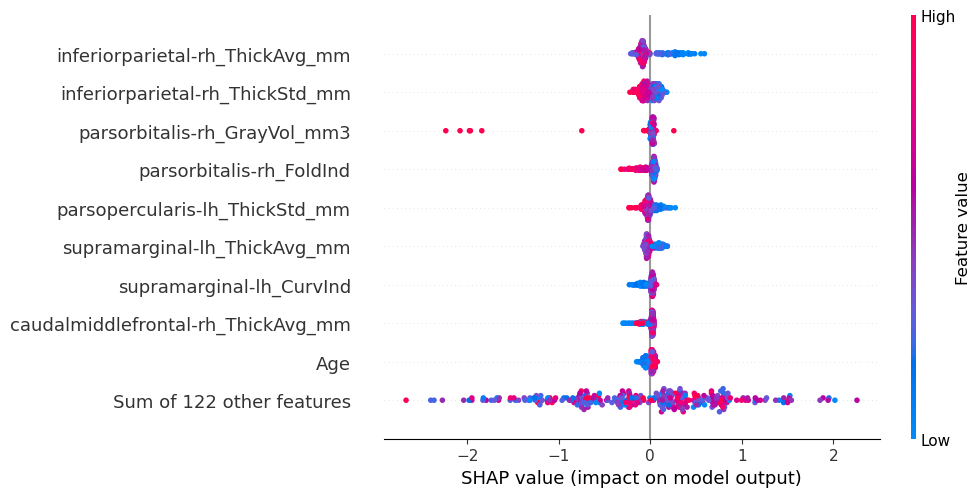

In [77]:
shap.plots.beeswarm(shap_values)